In [77]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("behavior-in-the-wild/LAMBDA")

df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

df = pd.concat([df_train, df_test], ignore_index=True)

print(ds)

DatasetDict({
    train: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 1964
    })
    test: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 219
    })
})


In [78]:
df.head()

,video_id,recall_score,youtube_id,ad_details
0,1437,0.33,fjE8uCbWEhQ,"{'Audio': '', 'Brand': 'Mondelez International..."
1,37,0.80,3DK8I80Yhgs,"{'Audio': 'Two full meals, $5.99 each. Marparo..."
2,1806,0.86,epvlMnOO3Ew,"{'Audio': 'Zsem tolik preponenta sebohhooztih,..."
3,1055,0.57,2ZsxgpRMBDg,{'Audio': 'Who doesn't dream about having smoo...
4,1839,0.33,QVfj-EYnZ6s,"{'Audio': '', 'Brand': 'Albertsons', 'Duration..."


In [79]:
df.isna().sum()

video_id        0
recall_score    0
youtube_id      0
ad_details      0
dtype: int64

In [80]:
df.describe()

,video_id,recall_score
count,2183.000000,2183.000000
mean,1385.741182,0.611429
std,776.266313,0.280094
min,1.000000,0.000000
25%,794.500000,0.430000
50%,1431.000000,0.670000
75%,2050.500000,0.830000
max,2711.000000,1.000000


In [81]:
ad_details_df = pd.DataFrame(df["ad_details"].tolist())
df_full = pd.concat([df.drop(columns=["ad_details"]), ad_details_df], axis=1)
df_full.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Scenes,Title
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,"[{'Colors': 'Black,Black,Gray,Dark_Gray,Off_Wh...",India - Bournvita - Basketball TV Commercial
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"[{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige...",Burger King Full Meals :15 TV Commercial
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,"[{'Colors': 'White,White', 'Description': 'sho...",Can print embellishment really attract new cli...
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"[{'Colors': 'White,White,Dark_Gray', 'Descript...",Smooth Sexy Hair | Ulta Beauty
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,"[{'Colors': 'Khaki,Brown,Off_White,Gray,Silver...",Dry-Brined Turkey Breast | Simple Weeknight Di...


In [82]:
import ast

df_full['Scenes'] = df_full['Scenes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_scenes(scenes):
    aggregated = {}
    for scene in scenes:
        for key, val in scene.items():
            if key == 'Number':
                continue
            col = f"scenes_{key.lower().replace(' ', '_')}"
            if col not in aggregated:
                aggregated[col] = set()
            if isinstance(val, str) and val.strip():
                for v in val.split(','):
                    aggregated[col].add(v.strip())

    return pd.Series({k: ', '.join(sorted(v)) for k, v in aggregated.items()})

scenes_agg = df_full['Scenes'].apply(aggregate_scenes)
df_full = pd.concat([df_full.drop(columns=['Scenes']), scenes_agg], axis=1)
df_full.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Title,scenes_colors,scenes_description,scenes_emotions,scenes_photography_style,scenes_tags,scenes_text_shown,scenes_tone,scenes_visual_complexity
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,India - Bournvita - Basketball TV Commercial,"Black, Brown, Dark_Brown, Dark_Gray, Dark_Gree...",shows a basketball court and a man standing in...,"abuse, achievement, anger, cheering, compete, ...","minimalist, sports","appear, arena, arm, athletic, balance, ball, b...","""What are you waiting for? Let's go, 'only onc...",neutral,"High, Low"
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,Burger King Full Meals :15 TV Commercial,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",shows a close up of two drinks with a glass in...,", bitter, confidence, confident, delicious, di...","commercial, composite, food","advertisement, alcohol, art, beverage, bite, b...","'""BK'Royal Crispy""', '""BK'RoyalCrispy""', '99',...","neutral, warm","High, Low"
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,Can print embellishment really attract new cli...,"Black, Cyan, Dark_Blue, Dark_Brown, Dark_Green...",shows a blue book on the ground with intricate...,"best, betrayal, compete, concentrated, confide...","business, editorial, minimalist, product","banknote, blanket, blue, book, bookshelf, box,...","'Kanovits Print', 'Owner', 'attract new client...","cool, neutral",Low
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,Smooth Sexy Hair | Ulta Beauty,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",'a person getting their hair washed by a woman...,", bad, care, comfort, comfortable, disgust, di...","commercial, composite, portrait, product","ball, barber, battery, beautiful, beauty salon...",", '&', '&SEAL', 'BEAUTY', 'COCONUT', 'COCONUTO...",neutral,"High, Low"
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,Dry-Brined Turkey Breast | Simple Weeknight Di...,"Black, Brown, Dark_Brown, Dark_Red, Gray, Khak...",'a person preparing food on a plate in a glass...,", bad, decay, good, protective, tasty","commercial, product","add, bowl, butter, chicken, chicken breast, cu...","'Albertsons', 'OF BREAST', 1/2 TBSP SUGAR', Al...",neutral,Low


In [83]:
df_full.isna().sum()

video_id                    0
recall_score                0
youtube_id                  0
Audio                       0
Brand                       0
Duration                    0
Orientation                 0
Pace                        0
Title                       0
scenes_colors               0
scenes_description          0
scenes_emotions             0
scenes_photography_style    0
scenes_tags                 0
scenes_text_shown           0
scenes_tone                 0
scenes_visual_complexity    0
dtype: int64

In [84]:
df_audio = df_full.copy()

In [85]:
from langdetect import detect_langs, DetectorFactory
import pandas as pd
import numpy as np
DetectorFactory.seed = 42


audio_col = "audio" if "audio" in df_full.columns else "Audio"

df_audio_check = df_full.copy()

df_audio_check[audio_col] = df_audio_check[audio_col].astype("string")

no_info_values = [
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a",
    "not found",
    "no info",
    "no information",
    "no audio",
    "blank"
]

def check_audio_info(text):    
    if pd.isna(text):
        return "blank_no_info"    
    text_clean = str(text).strip().lower()     
    if text_clean in no_info_values:
        return "blank_no_info"    
    return "has_info"

df_audio_check["audio_info_status"] = df_audio_check[audio_col].apply(check_audio_info)

info_summary = (
    df_audio_check["audio_info_status"]
    .value_counts()
    .reset_index()
)

info_summary.columns = ["audio_info_status", "count"]

info_summary["percentage"] = (
    info_summary["count"] / info_summary["count"].sum() * 100
).round(2)

info_summary

,audio_info_status,count,percentage
0,has_info,1235,56.57
1,blank_no_info,948,43.43


In [86]:
audio_col = "audio" if "audio" in df_audio_check.columns else "Audio"

def detect_english_or_not(text):
    text = str(text).strip()
    
    try:
        detected = detect_langs(text)
        best_lang = detected[0].lang
        best_prob = detected[0].prob
        
        if best_lang == "en" and best_prob >= 0.70:
            return "english"
        else:
            return "not_english"
            
    except:
        return "not_english"

mask_has_info = df_audio_check["audio_info_status"] == "has_info"
df_audio_check.loc[mask_has_info, "audio_language_group"] = (
    df_audio_check.loc[mask_has_info, audio_col].apply(detect_english_or_not)
)

language_summary_has_info = (
    df_audio_check.loc[mask_has_info, "audio_language_group"]
    .value_counts()
    .reset_index()
)

language_summary_has_info.columns = ["audio_language_group", "count"]

language_summary_has_info["percentage_among_has_info"] = (
    language_summary_has_info["count"] 
    / language_summary_has_info["count"].sum() * 100
).round(2)

language_summary_has_info

,audio_language_group,count,percentage_among_has_info
0,english,1137,92.06
1,not_english,98,7.94


In [87]:
audio_col = "audio" if "audio" in df_audio_check.columns else "Audio"
df_audio_en = df_audio_check[
    (df_audio_check["audio_info_status"] == "has_info") &
    (df_audio_check["audio_language_group"] == "english")
][["video_id", "youtube_id", "recall_score", audio_col]].copy()

df_audio_en.head()

,video_id,youtube_id,recall_score,Audio
1,37,3DK8I80Yhgs,0.80,"Two full meals, $5.99 each. Marparoya, crispy ..."
3,1055,2ZsxgpRMBDg,0.57,"Who doesn't dream about having smooth, silky, ..."
5,761,00STtvbodn8,0.43,"When you shop at Burlington, you'll find the l..."
7,2383,lgskk192v8Q,1.00,It's time that I told you the story of Aladdin...
8,2084,pdsBuJu7fnQ,1.00,You might be interested to know that your vehi...


In [88]:
print(df_audio_en)

      video_id   youtube_id  recall_score  \
1           37  3DK8I80Yhgs          0.80   
3         1055  2ZsxgpRMBDg          0.57   
5          761  00STtvbodn8          0.43   
7         2383  lgskk192v8Q          1.00   
8         2084  pdsBuJu7fnQ          1.00   
...        ...          ...           ...   
2173       781  VOigainILfI          0.83   
2175      2349  3AkEwhZdXN4          0.57   
2176      1941  SYaor7LG4Vk          0.43   
2178      2673  qvtYc3-U1rU          0.43   
2181      1759  d8RnGO2X3wQ          1.00   

                                                  Audio  
1     Two full meals, $5.99 each. Marparoya, crispy ...  
3     Who doesn't dream about having smooth, silky, ...  
5     When you shop at Burlington, you'll find the l...  
7     It's time that I told you the story of Aladdin...  
8     You might be interested to know that your vehi...  
...                                                 ...  
2173  From Disney Nature, meet Skye and her cubs Amb.

In [89]:
audio_col = "audio" if "audio" in df_audio_check.columns else "Audio"
df_audio_en = df_audio_check[
    (df_audio_check["audio_info_status"] == "has_info") &
    (df_audio_check["audio_language_group"] == "english")
].copy()

df_audio_en.info()
df_audio_en.head()


<class 'pandas.DataFrame'>
Index: 1137 entries, 1 to 2181
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   video_id                  1137 non-null   int64  
 1   recall_score              1137 non-null   float64
 2   youtube_id                1137 non-null   str    
 3   Audio                     1137 non-null   string 
 4   Brand                     1137 non-null   str    
 5   Duration                  1137 non-null   str    
 6   Orientation               1137 non-null   str    
 7   Pace                      1137 non-null   str    
 8   Title                     1137 non-null   str    
 9   scenes_colors             1137 non-null   str    
 10  scenes_description        1137 non-null   str    
 11  scenes_emotions           1137 non-null   str    
 12  scenes_photography_style  1137 non-null   str    
 13  scenes_tags               1137 non-null   str    
 14  scenes_text_shown       

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Title,scenes_colors,scenes_description,scenes_emotions,scenes_photography_style,scenes_tags,scenes_text_shown,scenes_tone,scenes_visual_complexity,audio_info_status,audio_language_group
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,Burger King Full Meals :15 TV Commercial,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",shows a close up of two drinks with a glass in...,", bitter, confidence, confident, delicious, di...","commercial, composite, food","advertisement, alcohol, art, beverage, bite, b...","'""BK'Royal Crispy""', '""BK'RoyalCrispy""', '99',...","neutral, warm","High, Low",has_info,english
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,Smooth Sexy Hair | Ulta Beauty,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",'a person getting their hair washed by a woman...,", bad, care, comfort, comfortable, disgust, di...","commercial, composite, portrait, product","ball, barber, battery, beautiful, beauty salon...",", '&', '&SEAL', 'BEAUTY', 'COCONUT', 'COCONUTO...",neutral,"High, Low",has_info,english
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,landscape,low,"You’ll want it all, at prices that’ll help you...","Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",shows a man standing next to a woman dancing i...,", attentive, casual, fancy, fantasy, friendly,...","commercial, editorial, lifestyle, product","apron, athletic, black, boutique, brand, brush...","'""other retailers' prices * every day""', '%', ...","neutral, warm","High, Low",has_info,english
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,landscape,medium,"Disney's Aladdin - ""Within"" TV Spot","Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...","shows a big yellow flame next to some logs, sh...",", adventure, adversity, amusing, celebration, ...","astrophotography, cityscape, composite, editor...","animal, anniversary, armor, balustrade, bengal...","'MAY 24', FROM', NO'","cool, neutral","High, Low",has_info,english
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,landscape,low,Double Pivot Mirror | Ford How-To | Ford,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...",dark photograph of a white lettering on a blue...,"accident, amazement, dangerous, emergency","commercial, editorial","attach, brand, car, dashboard, logo, rearview ...","'SUBSCRIBE', 'WATCH MORE', 'www, Ford', Knowin...","cool, neutral",Low,has_info,english


In [90]:
df_audio_en.describe()

,video_id,recall_score
count,1137.000000,1137.000000
mean,1365.331574,0.618417
std,784.348327,0.284487
min,1.000000,0.000000
25%,781.000000,0.430000
50%,1389.000000,0.670000
75%,2041.000000,0.860000
max,2711.000000,1.000000


In [91]:
columns_to_drop = [
    "Title",
    "scenes_description",
    "scenes_photography_style",
    "scenes_tags",
    "scenes_text_shown",
    "scenes_tone",
    "scenes_visual_complexity",
    "audio_info_status",
    "audio_language_group"
]
df_new= df_audio_en.drop(columns=columns_to_drop)


In [92]:
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,scenes_colors,scenes_emotions
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",", bitter, confidence, confident, delicious, di..."
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", bad, care, comfort, comfortable, disgust, di..."
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", attentive, casual, fancy, fantasy, friendly,..."
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,landscape,medium,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", adventure, adversity, amusing, celebration, ..."
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,landscape,low,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...","accident, amazement, dangerous, emergency"


In [93]:
df_new.describe()

,video_id,recall_score
count,1137.000000,1137.000000
mean,1365.331574,0.618417
std,784.348327,0.284487
min,1.000000,0.000000
25%,781.000000,0.430000
50%,1389.000000,0.670000
75%,2041.000000,0.860000
max,2711.000000,1.000000


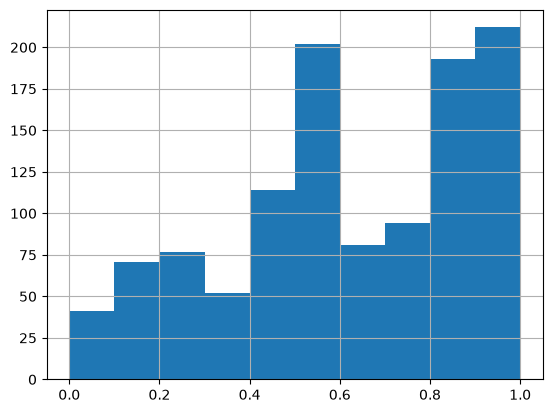

In [94]:
import matplotlib.pyplot as plt
df_new["recall_score"].hist()
plt.show()

In [95]:
df_new["duration_seconds"] = df_new["Duration"].str.extract(r"(\d+)").astype(float)

In [96]:
df_new.describe()

,video_id,recall_score,duration_seconds
count,1137.000000,1137.000000,1137.000000
mean,1365.331574,0.618417,33.394019
std,784.348327,0.284487,13.514451
min,1.000000,0.000000,6.000000
25%,781.000000,0.430000,25.000000
50%,1389.000000,0.670000,30.000000
75%,2041.000000,0.860000,45.000000
max,2711.000000,1.000000,59.000000


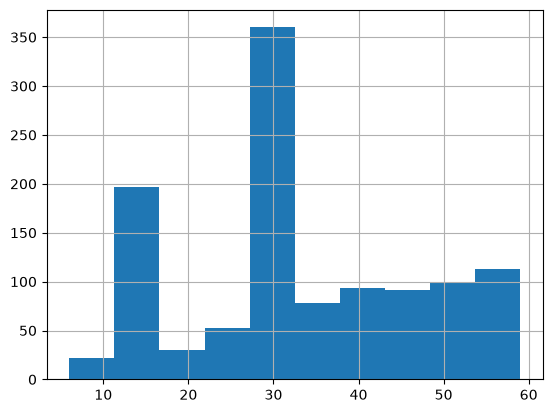

In [97]:
import matplotlib.pyplot as plt
df_new["duration_seconds"].hist()
plt.show()

In [98]:
correlation = df_new[
    ["duration_seconds", "recall_score"]
].corr(method="pearson")

print(correlation)

                  duration_seconds  recall_score
duration_seconds           1.00000       0.00568
recall_score               0.00568       1.00000


In [99]:
correlation = df_new[
    ["duration_seconds", "recall_score"]
].corr(method="spearman")

print(correlation)

                  duration_seconds  recall_score
duration_seconds          1.000000      0.004485
recall_score              0.004485      1.000000


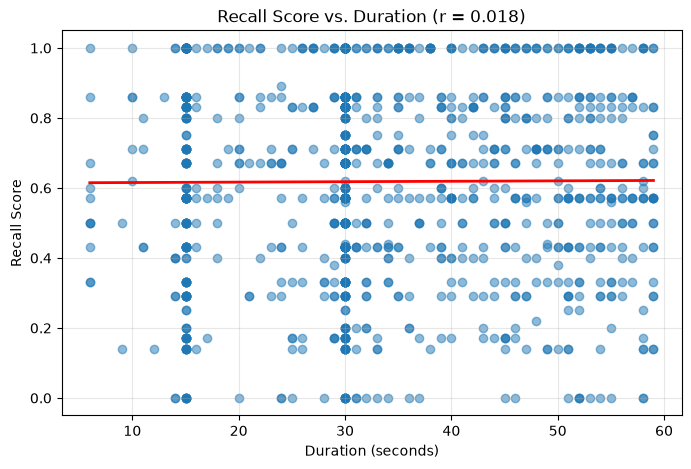

In [100]:
import numpy as np

plt.figure(figsize=(8, 5))
plt.scatter(df_new["duration_seconds"], df_new["recall_score"], alpha=0.5)

z = np.polyfit(df_new["duration_seconds"], df_new["recall_score"], 1)
x_line = np.linspace(df_new["duration_seconds"].min(), df_new["duration_seconds"].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=2)

plt.xlabel("Duration (seconds)")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Duration (r = 0.018)")
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
df_new["Brand"].value_counts()

Brand
Netflix                       78
Walt-Disney                   72
Ulta Beauty                   41
Costco                        30
Amazon                        24
                              ..
Williams                       1
The Coffee Bean & Tea Leaf     1
American Family Insurance      1
Stanley Black&Decker           1
Dollar General                 1
Name: count, Length: 232, dtype: int64

In [102]:
brand_summary = pd.DataFrame({
    "Count": df_new["Brand"].value_counts(),
    "Percentage": df_new["Brand"].value_counts(normalize=True) * 100
})

brand_summary["Percentage"] = brand_summary["Percentage"].round(2)

print(brand_summary.head(10))

                       Count  Percentage
Brand                                   
Netflix                   78        6.86
Walt-Disney               72        6.33
Ulta Beauty               41        3.61
Costco                    30        2.64
Amazon                    24        2.11
Homedepot                 23        2.02
Adobe                     22        1.93
Dick'S Sporting Goods     21        1.85
Nvidia                    19        1.67
Wayfair                   18        1.58


In [103]:
brand_counts = df_new["Brand"].value_counts()

print("Number of brands:", df_new["Brand"].nunique())
print("Brands appearing once:", (brand_counts == 1).sum())
print("Brands with fewer than 5 ads:", (brand_counts < 5).sum())

Number of brands: 232
Brands appearing once: 54
Brands with fewer than 5 ads: 169


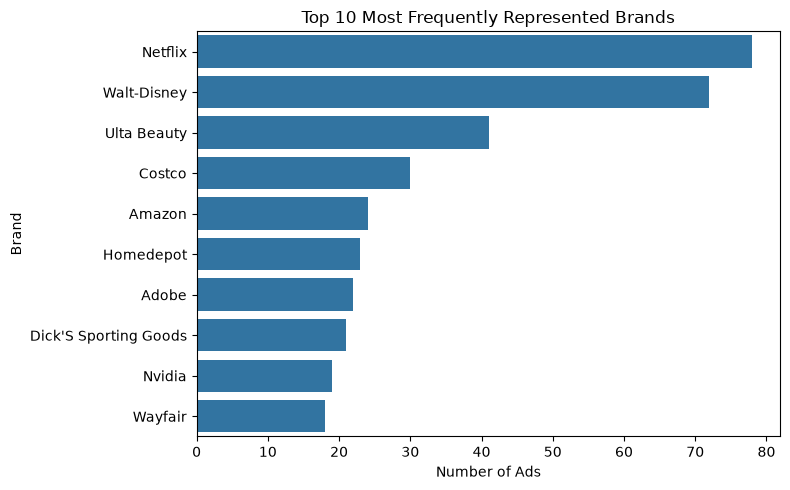

In [104]:
import seaborn as sns

top_10_brands = df_new["Brand"].value_counts().head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_10_brands.values,
    y=top_10_brands.index,
)

plt.xlabel("Number of Ads")
plt.ylabel("Brand")
plt.title("Top 10 Most Frequently Represented Brands")
plt.tight_layout()
plt.show()

In [105]:
brand_recall_stats = (
    df_new.groupby("Brand")["recall_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .query("count >= 10")
    .sort_values("mean", ascending=False)
    .round(3)
)

brand_recall_stats

,count,mean,median,std
Brand,,,,
Redbull,16,0.962,1.000,0.091
Ford Motor Company,12,0.904,1.000,0.150
Fitbit,10,0.885,0.845,0.105
Netflix,78,0.880,1.000,0.178
Nvidia,19,0.847,0.860,0.162
Skechers,12,0.840,0.860,0.176
Uber Technologies,16,0.834,0.860,0.164
Walt-Disney,72,0.792,0.830,0.178
Amazon,24,0.786,0.775,0.140


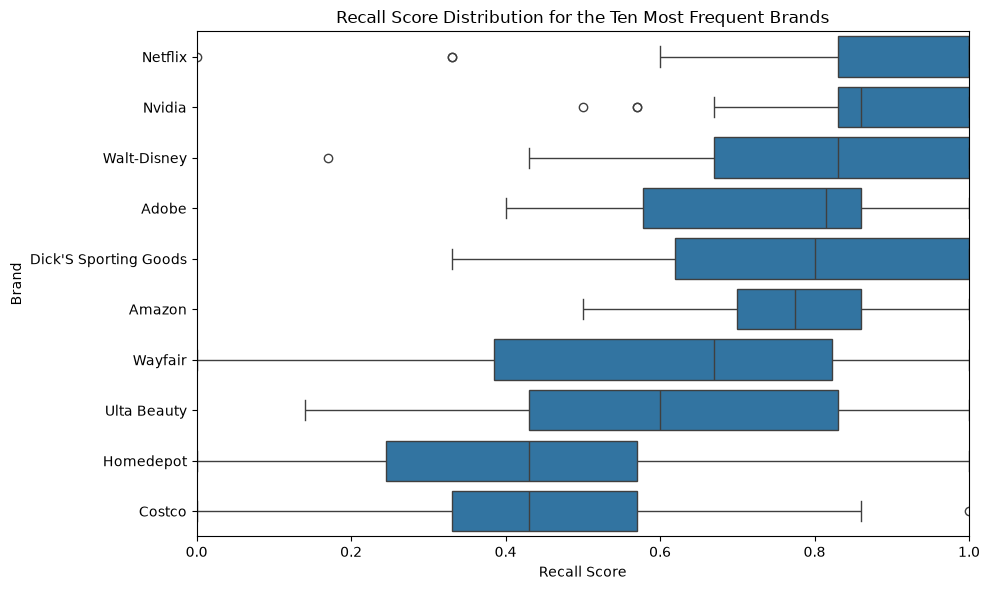

In [106]:
top_brands = df_new["Brand"].value_counts().head(10).index
top_brand_data = df_new[df_new["Brand"].isin(top_brands)].copy()

brand_order = (
    top_brand_data.groupby("Brand")["recall_score"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_brand_data,
    x="recall_score",
    y="Brand",
    order=brand_order,
   
)

plt.xlabel("Recall Score")
plt.ylabel("Brand")
plt.title("Recall Score Distribution for the Ten Most Frequent Brands")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [107]:
df_new["Pace"].value_counts()

Pace
low       716
medium    380
high       41
Name: count, dtype: int64

In [108]:
pace_summary = pd.DataFrame({
    "Count": df_new["Pace"].value_counts(),
    "Percentage": df_new["Pace"].value_counts(normalize=True) * 100
})

pace_summary["Percentage"] = pace_summary["Percentage"].round(2)
print(pace_summary)

        Count  Percentage
Pace                     
low       716       62.97
medium    380       33.42
high       41        3.61


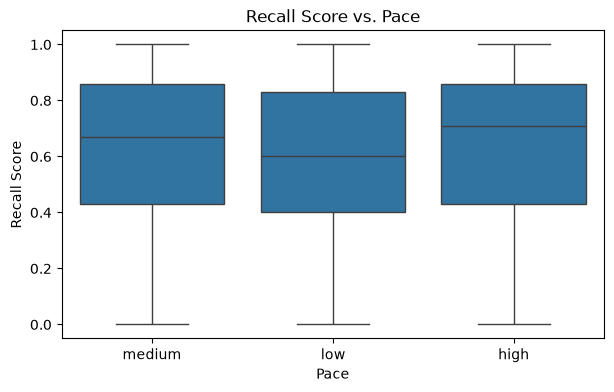

In [109]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_new,
    x="Pace",
    y="recall_score",
)

plt.xlabel("Pace")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Pace")
plt.show()

In [110]:
df_new["Orientation"].value_counts()

Orientation
landscape    1107
portrait       18
square         12
Name: count, dtype: int64

In [111]:
orientation_summary = pd.DataFrame({
    "Count": df_new["Orientation"].value_counts(),
    "Percentage": df_new["Orientation"].value_counts(normalize=True) * 100
})

orientation_summary["Percentage"] = orientation_summary["Percentage"].round(2)

print(orientation_summary)

             Count  Percentage
Orientation                   
landscape     1107       97.36
portrait        18        1.58
square          12        1.06


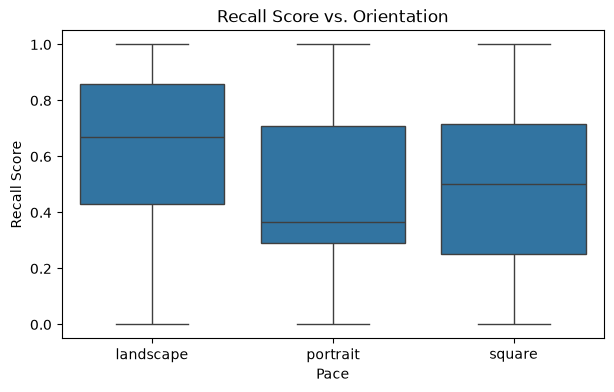

In [112]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_new,
    x="Orientation",
    y="recall_score",
)

plt.xlabel("Pace")
plt.ylabel("Recall Score")
plt.title("Recall Score vs. Orientation")
plt.show()

In [113]:
from collections import Counter

color_counts = Counter() 

df_new["scenes_colors"].dropna().apply(
    lambda x: color_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(color_counts).sort_values(ascending=False)

Black           1006
Dark_Brown       953
Gray             928
Dark_Gray        869
White            789
Brown            761
Dark_Blue        689
Mud_Green        638
Olive            590
Off_White        573
Orange           529
Khaki            510
Light_Blue       492
Dark_Pink        480
Dark_Green       458
Silver           447
Royal_Blue       445
Dark_Red         398
Cyan             376
Pink             364
Red              359
Emerald          358
Lavender         288
Maroon           254
Cream            253
Purple           208
Tan              200
Blue             142
Light_Green      138
Mustard          118
Turquoise        109
Beige             95
Yellow            90
Green             90
Plum              90
Lilac             84
Gold              48
Bright_Green      44
Magenta           42
Violet            40
dtype: int64

In [114]:
color_series = df_new["scenes_colors"]

n_nan = color_series.isna().sum()


def is_empty_color(value):
    if value is None:
        return False  

    if isinstance(value, float) and np.isnan(value):
        return False  

    if isinstance(value, str):
        return value.strip() == ""

    if isinstance(value, (list, tuple, set, dict)):
        return len(value) == 0

    return False

empty_mask = color_series.apply(is_empty_color)
n_empty = empty_mask.sum()

n_total = len(df_new)
n_valid = n_total - n_nan - n_empty

print("Total ads:", n_total)
print("Valid color data:", n_valid)
print("NaN/None:", n_nan)
print("Empty values:", n_empty)
print("Missing or empty:", n_nan + n_empty)

Total ads: 1137
Valid color data: 1080
NaN/None: 0
Empty values: 57
Missing or empty: 57


In [115]:
top_colors = [color for color, count in color_counts.most_common(15)]

top_colors

['Black',
 'Dark_Brown',
 'Gray',
 'Dark_Gray',
 'White',
 'Brown',
 'Dark_Blue',
 'Mud_Green',
 'Olive',
 'Off_White',
 'Orange',
 'Khaki',
 'Light_Blue',
 'Dark_Pink',
 'Dark_Green']

In [116]:
top_15_colors = pd.DataFrame(
    color_counts.most_common(15),
    columns=["Color", "Count"]
)

total_occurrences = sum(color_counts.values())

top_15_colors["Percentage"] = (
    top_15_colors["Count"] / total_occurrences * 100
).round(2)

top_15_colors



,Color,Count,Percentage
0,Black,1006,6.56
1,Dark_Brown,953,6.21
2,Gray,928,6.05
3,Dark_Gray,869,5.66
4,White,789,5.14
5,Brown,761,4.96
6,Dark_Blue,689,4.49
7,Mud_Green,638,4.16
8,Olive,590,3.84
9,Off_White,573,3.73


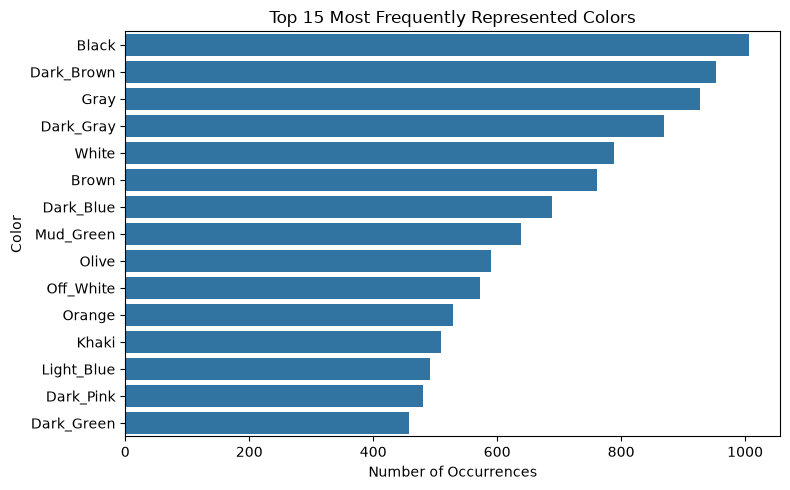

In [117]:
plt.figure(figsize=(8, 5))
import seaborn as sns
sns.barplot(
    data=top_15_colors,
    x="Count",
    y="Color"
)

plt.xlabel("Number of Occurrences")
plt.ylabel("Color")
plt.title("Top 15 Most Frequently Represented Colors")
plt.tight_layout()
plt.show()

In [118]:
df_color = df_new[["video_id", "recall_score"]].copy()
df_color.head()
for color in top_colors:
    df_color[f"color_{color}"] = df_new["scenes_colors"].fillna("").apply(
        lambda x: int(color in [c.strip() for c in x.split(",")])
    )

df_color.head()

,video_id,recall_score,color_Black,color_Dark_Brown,color_Gray,color_Dark_Gray,color_White,color_Brown,color_Dark_Blue,color_Mud_Green,color_Olive,color_Off_White,color_Orange,color_Khaki,color_Light_Blue,color_Dark_Pink,color_Dark_Green
1,37,0.80,1,1,0,0,0,1,0,1,1,0,1,1,0,0,0
3,1055,0.57,1,1,1,1,1,1,1,0,0,1,0,0,0,1,0
5,761,0.43,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1
7,2383,1.00,1,1,1,1,0,1,1,1,0,1,0,1,0,1,0
8,2084,1.00,1,0,1,1,1,0,1,0,0,0,0,0,1,0,0


In [119]:
top_colors_set = set(top_colors)

df_color["color_other"] = df_new["scenes_colors"].fillna("").apply(
    lambda value: int(
        any(
            color.strip() not in top_colors_set
            for color in value.split(",")
            if color.strip()
        )
    )
)

df_color.head()

,video_id,recall_score,color_Black,color_Dark_Brown,color_Gray,color_Dark_Gray,color_White,color_Brown,color_Dark_Blue,color_Mud_Green,color_Olive,color_Off_White,color_Orange,color_Khaki,color_Light_Blue,color_Dark_Pink,color_Dark_Green,color_other
1,37,0.80,1,1,0,0,0,1,0,1,1,0,1,1,0,0,0,1
3,1055,0.57,1,1,1,1,1,1,1,0,0,1,0,0,0,1,0,1
5,761,0.43,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1
7,2383,1.00,1,1,1,1,0,1,1,1,0,1,0,1,0,1,0,1
8,2084,1.00,1,0,1,1,1,0,1,0,0,0,0,0,1,0,0,1


In [120]:
df_color["color_other"].value_counts(normalize=True)

color_other
1    0.918206
0    0.081794
Name: proportion, dtype: float64

In [121]:
df_color = df_color.drop(columns="color_other")

               Color  Correlation  p-value
0        color_Black       0.0507   0.0876
7    color_Mud_Green       0.0499   0.0925
1   color_Dark_Brown       0.0293   0.3236
6    color_Dark_Blue       0.0274   0.3558
3    color_Dark_Gray       0.0270   0.3630
5        color_Brown       0.0230   0.4390
11       color_Khaki       0.0143   0.6303
14  color_Dark_Green       0.0133   0.6532
10      color_Orange      -0.0203   0.4942
13   color_Dark_Pink      -0.0383   0.1966
2         color_Gray      -0.0399   0.1784
9    color_Off_White      -0.0475   0.1092
12  color_Light_Blue      -0.0508   0.0871
8        color_Olive      -0.0867   0.0034
4        color_White      -0.0877   0.0031


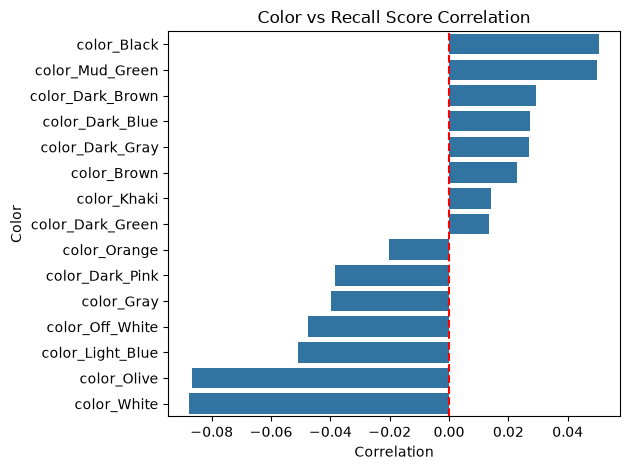

In [122]:
import seaborn as sns
from scipy.stats import pointbiserialr #Pearson Corr

color_cols = [c for c in df_color.columns if c.startswith("color_")]

results = []
for col in color_cols:
    corr, p_value = pointbiserialr(df_color[col], df_color["recall_score"].fillna(0))
    results.append({"Color": col, "Correlation": round(corr, 4), "p-value": round(p_value, 4)})

results_df = pd.DataFrame(results).sort_values("Correlation", ascending=False)
print(results_df)

sns.barplot(data=results_df, x="Correlation", y="Color")
plt.axvline(0, color="red", linestyle="--")
plt.title("Color vs Recall Score Correlation")
plt.tight_layout()
plt.show()

In [123]:
from collections import Counter

emotions_counts = Counter()  

df_new["scenes_emotions"].dropna().apply(
    lambda x: emotions_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(emotions_counts).sort_values(ascending=False)

happy           423
gift            369
good            345
smiling         261
emergency       257
               ... 
a laugh           1
torticilli        1
pleasantness      1
faithful          1
crave             1
Length: 946, dtype: int64

In [124]:
top_emotions = [emotion for emotion, count in emotions_counts.most_common(15)]

top_emotions

['happy',
 'gift',
 'good',
 'smiling',
 'emergency',
 'togetherness',
 'casual',
 'achievement',
 'smile',
 'holiday',
 'danger',
 'cheerful',
 'bad',
 'fun',
 'problem']

In [125]:
df_emotions_exploded = (
    df_new[["video_id", "recall_score", "scenes_emotions"]]
    .copy()
)

df_emotions_exploded["scenes_emotions"] = (
    df_emotions_exploded["scenes_emotions"]
    .fillna("")
    .str.split(",")
)

df_emotions_exploded = df_emotions_exploded.explode("scenes_emotions")

df_emotions_exploded["scenes_emotions"] = (
    df_emotions_exploded["scenes_emotions"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_emotions_exploded = (
    df_emotions_exploded[
        df_emotions_exploded["scenes_emotions"] != ""
    ]
    .drop_duplicates(subset=["video_id", "scenes_emotions"])
)

top_emotions = (
    df_emotions_exploded["scenes_emotions"]
    .value_counts()
    .head(15)
    .index
)

emotion_recall_stats = (
    df_emotions_exploded[
        df_emotions_exploded["scenes_emotions"].isin(top_emotions)
    ]
    .groupby("scenes_emotions")["recall_score"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
    .round(3)
)

emotion_recall_stats

,count,mean,median,std
scenes_emotions,,,,
fun,207,0.687,0.71,0.279
holiday,221,0.671,0.71,0.281
happy,423,0.662,0.71,0.269
bad,207,0.657,0.71,0.297
smile,227,0.655,0.71,0.277
danger,220,0.649,0.67,0.277
casual,250,0.647,0.67,0.276
gift,369,0.630,0.67,0.274
cheerful,209,0.628,0.67,0.274


In [126]:
df_emotions = df_new[["video_id", "recall_score"]].copy()
for emotion in top_emotions:
    df_emotions[f"emotion_{emotion}"] = df_new["scenes_emotions"].fillna("").apply(
        lambda x: int(emotion in [c.strip() for c in x.split(",")])
    )

df_emotions.head()

,video_id,recall_score,emotion_happy,emotion_gift,emotion_good,emotion_smiling,emotion_emergency,emotion_togetherness,emotion_casual,emotion_achievement,emotion_smile,emotion_holiday,emotion_danger,emotion_cheerful,emotion_bad,emotion_fun,emotion_problem
1,37,0.80,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1055,0.57,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0
5,761,0.43,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0
7,2383,1.00,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0
8,2084,1.00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


                 Emotion  Correlation  p-value
0          emotion_happy       0.1186   0.0001
13           emotion_fun       0.1136   0.0001
9        emotion_holiday       0.0904   0.0023
8          emotion_smile       0.0650   0.0284
12           emotion_bad       0.0639   0.0311
6         emotion_casual       0.0531   0.0733
10        emotion_danger       0.0526   0.0762
1           emotion_gift       0.0283   0.3404
11      emotion_cheerful       0.0167   0.5738
14       emotion_problem       0.0080   0.7871
5   emotion_togetherness       0.0024   0.9365
3        emotion_smiling      -0.0241   0.4169
7    emotion_achievement      -0.0242   0.4155
2           emotion_good      -0.0348   0.2409
4      emotion_emergency      -0.0912   0.0021


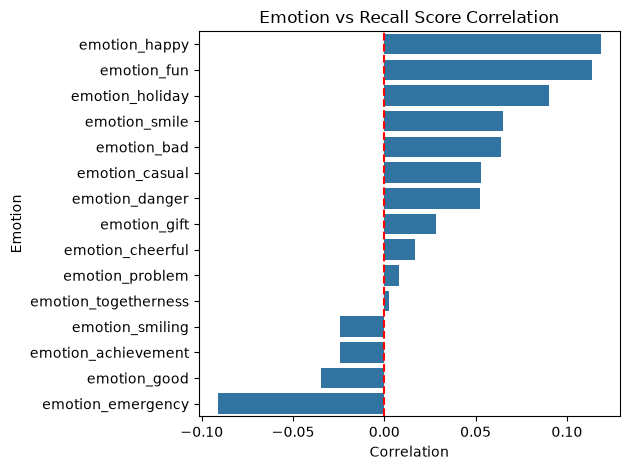

In [127]:
from scipy.stats import pointbiserialr #Pearson Corr

emotion_cols = [c for c in df_emotions.columns if c.startswith("emotion_")]

results = []
for col in emotion_cols:
    corr, p_value = pointbiserialr(df_emotions[col], df_emotions["recall_score"].fillna(0))
    results.append({"Emotion": col, "Correlation": round(corr, 4), "p-value": round(p_value, 4)})

results_df = pd.DataFrame(results).sort_values("Correlation", ascending=False)
print(results_df)

sns.barplot(data=results_df, x="Correlation", y="Emotion")
plt.axvline(0, color="red", linestyle="--")
plt.title("Emotion vs Recall Score Correlation")
plt.tight_layout()
plt.show()

In [128]:
#ANOVA 

In [129]:
top_15_brands = df_new["Brand"].value_counts().head(15).index
df_brand_top15 = df_new[df_new["Brand"].isin(top_15_brands)].copy()
print(df_brand_top15["Brand"].value_counts())

Brand
Netflix                  78
Walt-Disney              72
Ulta Beauty              41
Costco                   30
Amazon                   24
Homedepot                23
Adobe                    22
Dick'S Sporting Goods    21
Nvidia                   19
Wayfair                  18
Uber Technologies        16
Redbull                  16
Bedbath&Beyond           16
Cisco Systems            16
At&T                     14
Name: count, dtype: int64


In [130]:
from scipy.stats import f_oneway
brand_groups = [
    group["recall_score"].dropna().values
    for _, group in df_brand_top15.groupby("Brand")
]

f_stat, p_value = f_oneway(*brand_groups)

print(f"F-statistic Brand: {f_stat:.3f}")
print(f"p-value Brand: {p_value:.4f}")

F-statistic Brand: 17.274
p-value Brand: 0.0000


In [131]:
pace_summary = (
    df_new.groupby("Pace")["recall_score"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

pace_summary

,count,mean,std
Pace,,,
high,41,0.663659,0.279864
medium,380,0.654079,0.275111
low,716,0.596899,0.287801


In [132]:
pace_groups = [
    group["recall_score"].dropna().values
    for _, group in df_new.groupby("Pace")
]

f_stat_pace, p_value_pace = f_oneway(*pace_groups)

print(f"F-statistic Pace: {f_stat_pace:.3f}")
print(f"p-value Pace: {p_value_pace:.4f}")


F-statistic Pace: 5.597
p-value Pace: 0.0038


In [133]:
orientation_summary = (
    df_new.groupby("Orientation")["recall_score"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

orientation_summary

,count,mean,std
Orientation,,,
landscape,1107,0.621798,0.282911
portrait,18,0.499444,0.302703
square,12,0.485000,0.354003


In [134]:
orientation_groups = [
    group["recall_score"].dropna().values
    for _, group in df_new.groupby("Orientation")
]
f_stat_orientation, p_value_orientation = f_oneway(*orientation_groups)

print(f"F-statistic Orientation: {f_stat_orientation:.3f}")
print(f"p-value Orientation: {p_value_orientation:.4f}")

F-statistic Orientation: 2.982
p-value Orientation: 0.0511


In [135]:
#Spearman & Pearson: Duration vs Recall Score

In [136]:
from scipy.stats import pearsonr, spearmanr

data = df_new[["duration_seconds", "recall_score"]].dropna()

pearson_r, pearson_p = pearsonr(
    data["duration_seconds"], data["recall_score"]
)

spearman_rho, spearman_p = spearmanr(
    data["duration_seconds"], data["recall_score"]
)

print(f"Pearson:  r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman: ρ = {spearman_rho:.3f}, p = {spearman_p:.4f}")

Pearson:  r = 0.006, p = 0.8483
Spearman: ρ = 0.004, p = 0.8799


In [137]:
top_15_brands = df_new["Brand"].value_counts().head(15).index

df_new["Brand_grouped"] = df_new["Brand"].where(
    df_new["Brand"].isin(top_15_brands),
    "Other"
)
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,scenes_colors,scenes_emotions,duration_seconds,Brand_grouped
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",", bitter, confidence, confident, delicious, di...",15.0,Other
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", bad, care, comfort, comfortable, disgust, di...",39.0,Ulta Beauty
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", attentive, casual, fancy, fantasy, friendly,...",30.0,Other
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,landscape,medium,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", adventure, adversity, amusing, celebration, ...",30.0,Walt-Disney
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,landscape,low,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...","accident, amazement, dangerous, emergency",54.0,Other


In [138]:
df_new = pd.get_dummies(
    df_new,
    columns=["Brand_grouped"],
    dtype=int
)

df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,scenes_colors,scenes_emotions,...,Brand_grouped_Dick'S Sporting Goods,Brand_grouped_Homedepot,Brand_grouped_Netflix,Brand_grouped_Nvidia,Brand_grouped_Other,Brand_grouped_Redbull,Brand_grouped_Uber Technologies,Brand_grouped_Ulta Beauty,Brand_grouped_Walt-Disney,Brand_grouped_Wayfair
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",", bitter, confidence, confident, delicious, di...",...,0,0,0,0,1,0,0,0,0,0
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", bad, care, comfort, comfortable, disgust, di...",...,0,0,0,0,0,0,0,1,0,0
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,landscape,low,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", attentive, casual, fancy, fantasy, friendly,...",...,0,0,0,0,1,0,0,0,0,0
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,landscape,medium,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", adventure, adversity, amusing, celebration, ...",...,0,0,0,0,0,0,0,0,1,0
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,landscape,low,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...","accident, amazement, dangerous, emergency",...,0,0,0,0,1,0,0,0,0,0


In [139]:
df_new = pd.get_dummies(
    df_new,
    columns=["Pace", "Orientation"],
    dtype=int
)
print([col for col in df_new.columns if col.startswith("Pace_")])
print([col for col in df_new.columns if col.startswith("Orientation_")])

['Pace_high', 'Pace_low', 'Pace_medium']
['Orientation_landscape', 'Orientation_portrait', 'Orientation_square']


In [140]:
color_features = [
    col for col in df_color.columns
    if col.startswith("color_")
]

df_new[color_features] = df_color[color_features]

In [141]:
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,scenes_colors,scenes_emotions,duration_seconds,Brand_grouped_Adobe,...,color_Brown,color_Dark_Blue,color_Mud_Green,color_Olive,color_Off_White,color_Orange,color_Khaki,color_Light_Blue,color_Dark_Pink,color_Dark_Green
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",", bitter, confidence, confident, delicious, di...",15.0,0,...,1,0,1,1,0,1,1,0,0,0
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", bad, care, comfort, comfortable, disgust, di...",39.0,0,...,1,1,0,0,1,0,0,0,1,0
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", attentive, casual, fancy, fantasy, friendly,...",30.0,0,...,1,1,0,1,1,1,1,1,1,1
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", adventure, adversity, amusing, celebration, ...",30.0,0,...,1,1,1,0,1,0,1,0,1,0
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...","accident, amazement, dangerous, emergency",54.0,0,...,0,1,0,0,0,0,0,1,0,0


In [142]:
emotions_features = [
    col for col in df_emotions.columns
    if col.startswith("emotion_")
]

df_new[emotions_features] = df_emotions[emotions_features]
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,scenes_colors,scenes_emotions,duration_seconds,Brand_grouped_Adobe,...,emotion_togetherness,emotion_casual,emotion_achievement,emotion_smile,emotion_holiday,emotion_danger,emotion_cheerful,emotion_bad,emotion_fun,emotion_problem
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",", bitter, confidence, confident, delicious, di...",15.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", bad, care, comfort, comfortable, disgust, di...",39.0,0,...,0,0,0,1,0,0,0,1,0,0
5,761,0.43,00STtvbodn8,"When you shop at Burlington, you'll find the l...",Burlington Stores,30 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", attentive, casual, fancy, fantasy, friendly,...",30.0,0,...,0,1,0,0,1,0,0,0,0,0
7,2383,1.00,lgskk192v8Q,It's time that I told you the story of Aladdin...,Walt-Disney,30 second,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",", adventure, adversity, amusing, celebration, ...",30.0,0,...,0,0,0,0,1,0,0,0,0,0
8,2084,1.00,pdsBuJu7fnQ,You might be interested to know that your vehi...,Ford Motor Company,54 second,"Black, Dark_Blue, Dark_Gray, Gray, Lavender, L...","accident, amazement, dangerous, emergency",54.0,0,...,0,0,0,0,0,0,0,0,0,0


In [143]:
print(df_new.columns.tolist())

['video_id', 'recall_score', 'youtube_id', 'Audio', 'Brand', 'Duration', 'scenes_colors', 'scenes_emotions', 'duration_seconds', 'Brand_grouped_Adobe', 'Brand_grouped_Amazon', 'Brand_grouped_At&T', 'Brand_grouped_Bedbath&Beyond', 'Brand_grouped_Cisco Systems', 'Brand_grouped_Costco', "Brand_grouped_Dick'S Sporting Goods", 'Brand_grouped_Homedepot', 'Brand_grouped_Netflix', 'Brand_grouped_Nvidia', 'Brand_grouped_Other', 'Brand_grouped_Redbull', 'Brand_grouped_Uber Technologies', 'Brand_grouped_Ulta Beauty', 'Brand_grouped_Walt-Disney', 'Brand_grouped_Wayfair', 'Pace_high', 'Pace_low', 'Pace_medium', 'Orientation_landscape', 'Orientation_portrait', 'Orientation_square', 'color_Black', 'color_Dark_Brown', 'color_Gray', 'color_Dark_Gray', 'color_White', 'color_Brown', 'color_Dark_Blue', 'color_Mud_Green', 'color_Olive', 'color_Off_White', 'color_Orange', 'color_Khaki', 'color_Light_Blue', 'color_Dark_Pink', 'color_Dark_Green', 'emotion_happy', 'emotion_gift', 'emotion_good', 'emotion_smili

In [144]:
#train/val/test: 60/20/20

In [145]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df_new,
    test_size=0.20,
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (681, 61)
Validation: (228, 61)
Test: (228, 61)


In [182]:
emotions_feature = [
    col for col in df_new.columns
    if col.startswith("emotion_")
]
color_feature = [
    col for col in df_new.columns
    if col.startswith("color_")
]

brand_feature = [
    col for col in df_new.columns
    if col.startswith("Brand_grouped_")
]

Pace_feature = [
    col for col in df_new.columns
    if col.startswith("Pace_")
]
Orientation_feature = [
    col for col in df_new.columns
    if col.startswith("Orientation_")
]

duration_feature = ["duration_seconds"]

In [147]:
#TFIDF

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)
X_train_tfidf = tfidf.fit_transform(train_df["Audio"])
X_val_tfidf = tfidf.transform(val_df["Audio"])
X_test_tfidf = tfidf.transform(test_df["Audio"])

In [184]:
import pandas as pd
import numpy as np
import re
import torch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score

In [161]:
#BERT

In [162]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = bert_model.to(device)

print("Device:", device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6857.32it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu


In [163]:
def get_bert_embeddings(texts, batch_size=8, max_length=128):
    bert_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
      
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    all_embeddings = np.vstack(all_embeddings)
    
    return all_embeddings

In [167]:
X_train_bert = get_bert_embeddings(
    train_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_bert = get_bert_embeddings(
    val_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_bert = get_bert_embeddings(
    test_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

In [168]:
#distilbert

In [169]:
distilbert_model_name = "distilbert-base-uncased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
distilbert_model = AutoModel.from_pretrained(distilbert_model_name)

distilbert_model = distilbert_model.to(device)
distilbert_model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7135.23it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [170]:
def get_distilbert_embeddings(texts, batch_size=8, max_length=128):
    distilbert_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = distilbert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = distilbert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
       
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    all_embeddings = np.vstack(all_embeddings)
    
    return all_embeddings

In [171]:
X_train_distilbert = get_distilbert_embeddings(
    train_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_distilbert = get_distilbert_embeddings(
    val_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_distilbert = get_distilbert_embeddings(
    test_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

In [172]:
#RoBERTa

In [173]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
roberta_model = AutoModel.from_pretrained(model_name)

roberta_model = roberta_model.to(device)
roberta_model.eval()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6857.59it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

In [174]:
def get_roberta_embeddings(texts, batch_size=8, max_length=128):
    roberta_model.eval()
    
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)
        
        with torch.no_grad():
            outputs = roberta_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        
        token_embeddings = outputs.last_hidden_state
        
        attention_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * attention_mask_expanded, dim=1)
        sum_mask = torch.clamp(attention_mask_expanded.sum(dim=1), min=1e-9)
        mean_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

In [175]:
X_train_roberta = get_roberta_embeddings(
    train_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_val_roberta = get_roberta_embeddings(
    val_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)

X_test_roberta = get_roberta_embeddings(
    test_df["Audio"].tolist(),
    batch_size=8,
    max_length=128
)


In [176]:
#MiniLM

In [177]:
from sentence_transformers import SentenceTransformer

minilm_model = SentenceTransformer("all-MiniLM-L6-v2")

X_train_minilm = minilm_model.encode(
    train_df["Audio"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)

X_val_minilm = minilm_model.encode(
    val_df["Audio"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)

X_test_minilm = minilm_model.encode(
    test_df["Audio"].fillna("").astype(str).tolist(),
    batch_size=8,
    show_progress_bar=True
)


Batches: 100%|██████████| 29/29 [00:00<00:00, 35.50it/s]


In [178]:
feature_sets = {
    "TF-IDF": (X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "BERT": (X_train_bert, X_val_bert, X_test_bert),
    "DistilBERT": (X_train_distilbert, X_val_distilbert, X_test_distilbert),
    "RoBERTa": (X_train_roberta, X_val_roberta, X_test_roberta),
    "MiniLM": (X_train_minilm, X_val_minilm, X_test_minilm)
}

In [ ]:
#features = "MiniLM"

#X_train, X_val, X_test = feature_sets[features]

#y_train = train_df["recall_score"]
#y_val = val_df["recall_score"]
#y_test = test_df["recall_score"]

In [180]:
#LR: Duration vs RS

In [185]:
features = duration_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Duration:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Duration:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Duration", round(r2_score(y_test, y_test_pred), 4))

Train R² Duration: 0.0012
Validation R² Duration: -0.0038
Test R² Duration -0.0053


In [186]:
#LR: Brand vs RS

In [187]:
features = brand_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Brand_grouped:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Brand_grouped:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Brand_grouped", round(r2_score(y_test, y_test_pred), 4))

Train R² Brand_grouped: 0.1851
Validation R² Brand_grouped: 0.1631
Test R² Brand_grouped 0.1911


In [188]:
#LR: Pace vs RS

In [189]:
features = Pace_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Pace:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Pace:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Pace", round(r2_score(y_test, y_test_pred), 4))

Train R² Pace: 0.0095
Validation R² Pace: 0.0233
Test R² Pace -0.0066


In [190]:
#LR: Orientation 

In [191]:
features = Pace_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Pace:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Pace:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Pace", round(r2_score(y_test, y_test_pred), 4))

Train R² Pace: 0.0095
Validation R² Pace: 0.0233
Test R² Pace -0.0066


In [192]:
features = Orientation_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Orientation:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Orientation:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Orientation", round(r2_score(y_test, y_test_pred), 4))

Train R² Orientation: 0.0042
Validation R² Orientation: 0.0024
Test R² Orientation 0.0063


In [193]:
features = color_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Color top 15:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Color top 15:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Color top 15", round(r2_score(y_test, y_test_pred), 4))

Train R² Color top 15: 0.0403
Validation R² Color top 15: 0.0015
Test R² Color top 15 0.049


In [194]:
features = emotions_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Emotion top 15:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Emotion top 15:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Emotion top 15", round(r2_score(y_test, y_test_pred), 4))

Train R² Emotion top 15: 0.0435
Validation R² Emotion top 15: 0.0481
Test R² Emotion top 15 0.037


In [195]:
features = emotions_feature + color_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Emotion + Color top 15:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Emotion + Color top 15:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Emotion + Color top 15", round(r2_score(y_test, y_test_pred), 4))

Train R² Emotion + Color top 15: 0.0789
Validation R² Emotion + Color top 15: 0.0464
Test R² Emotion + Color top 15 0.0915


In [196]:
features = emotions_feature + color_feature + brand_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Brand + Emotion + Color top 15:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Brand + Emotion + Color top 15:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Brand + Emotion + Color top 15:", round(r2_score(y_test, y_test_pred), 4))

Train R² Brand + Emotion + Color top 15: 0.2246
Validation R² Brand + Emotion + Color top 15: 0.1861
Test R² Brand + Emotion + Color top 15: 0.2415


In [197]:
features = Pace_feature + brand_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² Brand + Pace:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Brand + Pace:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Brand + Pace:", round(r2_score(y_test, y_test_pred), 4))

Train R² Brand + Pace: 0.2011
Validation R² Brand + Pace: 0.1878
Test R² Brand + Pace: 0.175


In [201]:
features = color_feature + brand_feature + emotions_feature + duration_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² color_feature + brand_feature + emotions_feature + duration_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² color_feature + brand_feature + emotions_feature + duration_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² color_feature + brand_feature + emotions_feature + duration_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² color_feature + brand_feature + emotions_feature + duration_feature: 0.2247
Validation R² color_feature + brand_feature + emotions_feature + duration_feature: 0.1853
Test R² color_feature + brand_feature + emotions_feature + duration_feature: 0.2404


In [202]:
features = color_feature + brand_feature + emotions_feature + duration_feature + Pace_feature + Orientation_feature
target = "recall_score"


# Train
X_train = train_df[features]
y_train = train_df[target]

# Validation
X_val = val_df[features]
y_val = val_df[target]

# Test
X_test = test_df[features]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² all:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² all:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² all", round(r2_score(y_test, y_test_pred), 4))

Train R² all: 0.2429
Validation R² all: 0.2005
Test R² all 0.2373


In [204]:
features = "TF-IDF"
target = "recall_score"


X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² TF-IDF:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² TF-IDF:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² TF-IDF:", round(r2_score(y_test, y_test_pred), 4))

Train R² TF-IDF: 0.987
Validation R² TF-IDF: -0.3462
Test R² TF-IDF: -0.3292


In [205]:
features =  "BERT"
target = "recall_score"


X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² BERT:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² BERT:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² BERT:", round(r2_score(y_test, y_test_pred), 4))

Train R² BERT: 0.9988
Validation R² BERT: -18.0634
Test R² BERT: -19.7368


In [206]:
features =  "DistilBERT"
target = "recall_score"


X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² DistilBERT:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² DistilBERT:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² DistilBERT:", round(r2_score(y_test, y_test_pred), 4))

Train R² DistilBERT: 0.9988
Validation R² DistilBERT: -8.9013
Test R² DistilBERT: -9.2569


In [207]:
features =  "RoBERTa"
target = "recall_score"


X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² RoBERTa:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² RoBERTa:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² RoBERTa:", round(r2_score(y_test, y_test_pred), 4))

Train R² RoBERTa: 0.999
Validation R² RoBERTa: -9.2886
Test R² RoBERTa: -10.9393


In [208]:
features =  "MiniLM"
target = "recall_score"


X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred = lr.predict(X_train)
y_val_pred = lr.predict(X_val)
y_test_pred = lr.predict(X_test)

# R²
print("Train R² MiniLM:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² MiniLM:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² MiniLM:", round(r2_score(y_test, y_test_pred), 4))

Train R² MiniLM: 0.6023
Validation R² MiniLM: -0.7939
Test R² MiniLM: -0.917


In [209]:
#Random Forest

In [217]:
from sklearn.ensemble import RandomForestRegressor

features = duration_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² duration_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² duration_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² duration_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² duration_feature: 0.0421
Validation R² duration_feature: -0.0407
Test R² duration_feature: -0.0254


In [216]:
from sklearn.ensemble import RandomForestRegressor

features = brand_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² brand_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² brand_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² brand_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² brand_feature: 0.1457
Validation R² brand_feature: 0.1053
Test R² brand_feature: 0.1226


In [212]:
from sklearn.ensemble import RandomForestRegressor

features = Pace_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² Pace_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Pace_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Pace_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² Pace_feature: 0.0095
Validation R² Pace_feature: 0.0237
Test R² Pace_feature: -0.0072


In [213]:
from sklearn.ensemble import RandomForestRegressor

features = Orientation_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² Orientation_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² Orientation_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² Orientation_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² Orientation_feature: 0.0021
Validation R² Orientation_feature: -0.0002
Test R² Orientation_feature: 0.0021


In [214]:
features = color_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² color_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² color_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² color_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² color_feature: 0.082
Validation R² color_feature: 0.0058
Test R² color_feature: 0.0389


In [215]:
features = emotions_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² emotions_feature:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² emotions_feature:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² emotions_feature:", round(r2_score(y_test, y_test_pred), 4))

Train R² emotions_feature: 0.0767
Validation R² emotions_feature: 0.0326
Test R² emotions_feature: 0.0402


In [222]:
features = brand_feature + duration_feature + Pace_feature + Orientation_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² General :", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² General:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² General:", round(r2_score(y_test, y_test_pred), 4))

Train R² General : 0.1765
Validation R² General: 0.1128
Test R² General: 0.1201


In [225]:
features = brand_feature + Orientation_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² brand_feature + Orientation_feature  :", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² brand_feature + Orientation_feature :", round(r2_score(y_val, y_val_pred), 4))
print("Test R² brand_feature + Orientation_feature :", round(r2_score(y_test, y_test_pred), 4))

Train R² brand_feature + Orientation_feature  : 0.1461
Validation R² brand_feature + Orientation_feature : 0.1034
Test R² brand_feature + Orientation_feature : 0.1233


In [224]:
features = brand_feature + Pace_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² brand_feature + Pace_feature  :", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² brand_feature + Pace_feature :", round(r2_score(y_val, y_val_pred), 4))
print("Test R² brand_feature + Pace_feature :", round(r2_score(y_test, y_test_pred), 4))

Train R² brand_feature + Pace_feature  : 0.1674
Validation R² brand_feature + Pace_feature : 0.1167
Test R² brand_feature + Pace_feature : 0.108


In [223]:
features = brand_feature + duration_feature 
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² brand_feature + duration_feature  :", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² brand_feature + duration_feature :", round(r2_score(y_val, y_val_pred), 4))
print("Test R² brand_feature + duration_feature :", round(r2_score(y_test, y_test_pred), 4))

Train R² brand_feature + duration_feature  : 0.161
Validation R² brand_feature + duration_feature : 0.0983
Test R² brand_feature + duration_feature : 0.1342


In [221]:
features = emotions_feature + color_feature + brand_feature + duration_feature + Pace_feature + Orientation_feature
target = "recall_score"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

print("Train R² all:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² all:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² all:", round(r2_score(y_test, y_test_pred), 4))

Train R² all: 0.217
Validation R² all: 0.1144
Test R² all: 0.1443


In [226]:
features = "TF-IDF"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² TF-IDF:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² TF-IDF:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² TF-IDF:", round(r2_score(y_test, y_test_pred), 4))

Train R² TF-IDF: 0.0996
Validation R² TF-IDF: 0.0458
Test R² TF-IDF: 0.0287


In [227]:
features =  "BERT"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² BERT:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² BERT:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² BERT:", round(r2_score(y_test, y_test_pred), 4))

Train R² BERT: 0.3752
Validation R² BERT: 0.0769
Test R² BERT: 0.0892


In [228]:
features =  "DistilBERT"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² DistilBERT:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² DistilBERT:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² DistilBERT:", round(r2_score(y_test, y_test_pred), 4))

Train R² DistilBERT: 0.3755
Validation R² DistilBERT: 0.082
Test R² DistilBERT: 0.1101


In [229]:
features =  "RoBERTa"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² RoBERTa:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² RoBERTa:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² RoBERTa:", round(r2_score(y_test, y_test_pred), 4))

Train R² RoBERTa: 0.386
Validation R² RoBERTa: 0.0967
Test R² RoBERTa: 0.0888


In [230]:
features =  "MiniLM"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² MiniLM:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² MiniLM:", round(r2_score(y_val, y_val_pred), 4))
print("Test R² MiniLM:", round(r2_score(y_test, y_test_pred), 4))

Train R² MiniLM: 0.3643
Validation R² MiniLM: 0.0623
Test R² MiniLM: 0.0815


In [232]:
#DistilBERT + Brand

In [233]:
import numpy as np

# DistilBERT
X_train_text = X_train_distilbert
X_val_text = X_val_distilbert
X_test_text = X_test_distilbert

# Brand
X_train_brand = train_df[brand_feature].to_numpy()
X_val_brand = val_df[brand_feature].to_numpy()
X_test_brand = test_df[brand_feature].to_numpy()

# Combine DistilBERT + Brand
X_train = np.hstack([X_train_text, X_train_brand])
X_val = np.hstack([X_val_text, X_val_brand])
X_test = np.hstack([X_test_text, X_test_brand])

# Target
y_train = train_df["recall_score"]
y_val = val_df["recall_score"]
y_test = test_df["recall_score"]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² DistilBERT + Brand:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² DistilBERT + Brand", round(r2_score(y_val, y_val_pred), 4))
print("Test R² DistilBERT + Brand:", round(r2_score(y_test, y_test_pred), 4))

Train R² DistilBERT + Brand: 0.4051
Validation R² DistilBERT + Brand 0.1209
Test R² DistilBERT + Brand: 0.1674


In [256]:
rf_metadata_sets = {
    "Duration": duration_feature,
    "Brand": brand_feature,
    "Pace": Pace_feature,
    "Orientation": Orientation_feature,
    "Color": color_feature,
    "Emotion": emotions_feature,

    "Brand + Pace":
        brand_feature + Pace_feature,

    "Brand + Orientation":
        brand_feature + Orientation_feature,

    "Brand + Duration":
        brand_feature + duration_feature,

    "General":
        duration_feature
        + brand_feature
        + Pace_feature
        + Orientation_feature,

    "Visual":
        emotions_feature + color_feature,

    "Brand + Visual":
        brand_feature
        + emotions_feature
        + color_feature,

    "Brand + Visual + Duration":
        brand_feature
        + emotions_feature
        + color_feature
        + duration_feature,

    "General + Visual":
        duration_feature
        + brand_feature
        + Pace_feature
        + Orientation_feature
        + emotions_feature
        + color_feature
}

In [257]:
features = "Brand + Pace"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + Brand + Pace
Train R²: 0.4068
Validation R²: 0.1275
Test R²: 0.1654


In [258]:
features = "Brand + Orientation"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + Brand + Orientation
Train R²: 0.4058
Validation R²: 0.1268
Test R²: 0.1645


In [259]:
features =  "Brand + Duration"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + Brand + Duration
Train R²: 0.4032
Validation R²: 0.127
Test R²: 0.1683


In [260]:
features =  "General"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + General
Train R²: 0.4022
Validation R²: 0.1278
Test R²: 0.1659


In [261]:
features =  "Visual"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + Visual
Train R²: 0.3756
Validation R²: 0.0905
Test R²: 0.117


In [262]:
features =  "Brand + Visual + Duration"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + Brand + Visual + Duration
Train R²: 0.3978
Validation R²: 0.1209
Test R²: 0.1604


In [263]:
features =  "General + Visual"

metadata_cols = rf_metadata_sets[features]

X_train = np.hstack([
    X_train_distilbert,
    train_df[metadata_cols].to_numpy()
])

X_val = np.hstack([
    X_val_distilbert,
    val_df[metadata_cols].to_numpy()
])

X_test = np.hstack([
    X_test_distilbert,
    test_df[metadata_cols].to_numpy()
])


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("DistilBERT +", features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Validation R²:", round(r2_score(y_val, val_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

DistilBERT + General + Visual
Train R²: 0.408
Validation R²: 0.1184
Test R²: 0.1673


In [234]:
#DistilBERT + Brand + Color + Emotion

In [235]:
feature_sets["DistilBERT + Brand + Color + Emotion"] = (
    np.hstack([
        X_train_distilbert,
        train_df[brand_feature].to_numpy(),
        train_df[color_feature].to_numpy(),
        train_df[emotions_feature].to_numpy()
    ]),

    np.hstack([
        X_val_distilbert,
        val_df[brand_feature].to_numpy(),
        val_df[color_feature].to_numpy(),
        val_df[emotions_feature].to_numpy()
    ]),

    np.hstack([
        X_test_distilbert,
        test_df[brand_feature].to_numpy(),
        test_df[color_feature].to_numpy(),
        test_df[emotions_feature].to_numpy()
    ])
)

features = "DistilBERT + Brand + Color + Emotion"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# R²
print("Train R² DiDistilBERT + Brand + Color + Emotion:", round(r2_score(y_train, y_train_pred), 4))
print("Validation R² DistilBERT + Brand + Color + Emotion", round(r2_score(y_val, y_val_pred), 4))
print("Test R² DistilBERT + Brand + Color + Emotion:", round(r2_score(y_test, y_test_pred), 4))

Train R² DiDistilBERT + Brand + Color + Emotion: 0.406
Validation R² DistilBERT + Brand + Color + Emotion 0.1251
Test R² DistilBERT + Brand + Color + Emotion: 0.1606


In [236]:
#RIDGE

In [265]:
feature_sets = {
    "Duration": (
        train_df[duration_feature],
        val_df[duration_feature],
        test_df[duration_feature]
    ),

    "Brand": (
        train_df[brand_feature],
        val_df[brand_feature],
        test_df[brand_feature]
    ),

    "Pace": (
        train_df[Pace_feature],
        val_df[Pace_feature],
        test_df[Pace_feature]
    ),

    "Orientation": (
        train_df[Orientation_feature],
        val_df[Orientation_feature],
        test_df[Orientation_feature]
    ),

    "Color": (
        train_df[color_feature],
        val_df[color_feature],
        test_df[color_feature]
    ),

    "Emotion": (
        train_df[emotions_feature],
        val_df[emotions_feature],
        test_df[emotions_feature]
    ),

    "TF-IDF": (
        X_train_tfidf,
        X_val_tfidf,
        X_test_tfidf
     ),
    
    "BERT": (
        X_train_bert,
        X_val_bert,
        X_test_bert
    ),

    "DistilBERT": (
        X_train_distilbert,
        X_val_distilbert,
        X_test_distilbert
    ),

    "RoBERTa": (
        X_train_roberta,
        X_val_roberta,
        X_test_roberta
    ),

    "MiniLM": (
        X_train_minilm,
        X_val_minilm,
        X_test_minilm
    )
}

In [272]:
from sklearn.linear_model import Ridge
features = "BERT"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R²": r2_score(y_train, train_preds),
        "Validation R²": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R²",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT,100.00,0.243077,0.108428
4,BERT,50.00,0.317444,0.108277
6,BERT,150.00,0.205521,0.103249
7,BERT,200.00,0.181639,0.097941
3,BERT,10.00,0.523553,0.036896
2,BERT,1.00,0.804803,-0.414095
1,BERT,0.10,0.954448,-1.887689
0,BERT,0.01,0.994597,-4.730958


In [253]:
from sklearn.linear_model import Ridge
features = "TF-IDF"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
3,TF-IDF,5.00,0.317518,0.051116
4,TF-IDF,10.00,0.192857,0.036670
2,TF-IDF,1.00,0.694694,0.033960
5,TF-IDF,50.00,0.047335,0.009006
6,TF-IDF,100.00,0.024402,0.003601
7,TF-IDF,200.00,0.012396,0.000658
1,TF-IDF,0.10,0.963457,-0.144041
0,TF-IDF,0.01,0.986367,-0.294937


In [273]:
from sklearn.linear_model import Ridge
features = "DistilBERT"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
6,DistilBERT,100.00,0.189802,0.103970
5,DistilBERT,50.00,0.244306,0.103182
7,DistilBERT,150.00,0.162257,0.098881
8,DistilBERT,200.00,0.144601,0.093581
4,DistilBERT,10.00,0.403344,0.030902
3,DistilBERT,5.00,0.481231,-0.035550
2,DistilBERT,1.00,0.665392,-0.286453
1,DistilBERT,0.10,0.883341,-1.311793
0,DistilBERT,0.01,0.979574,-4.180605


In [270]:
from sklearn.linear_model import Ridge
features = "RoBERTa"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
4,RoBERTa,10.00,0.297604,0.091852
5,RoBERTa,50.00,0.167303,0.090190
6,RoBERTa,100.00,0.127685,0.078476
3,RoBERTa,5.00,0.370494,0.073178
7,RoBERTa,150.00,0.108552,0.070558
8,RoBERTa,200.00,0.096515,0.064750
2,RoBERTa,1.00,0.568201,-0.042272
1,RoBERTa,0.10,0.825648,-0.484861
0,RoBERTa,0.01,0.960681,-1.868432


In [271]:
from sklearn.linear_model import Ridge
features = "MiniLM"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
3,MiniLM,5.00,0.244811,0.094419
4,MiniLM,10.00,0.183697,0.086981
2,MiniLM,1.00,0.388952,0.054747
5,MiniLM,50.00,0.072795,0.043474
6,MiniLM,100.00,0.043050,0.025968
7,MiniLM,150.00,0.030677,0.018125
8,MiniLM,200.00,0.023848,0.013674
1,MiniLM,0.10,0.539048,-0.170346
0,MiniLM,0.01,0.595682,-0.541248


In [274]:
general_feature = (
    duration_feature
    + brand_feature
    + Pace_feature
    + Orientation_feature
)

visual_feature = (
    emotions_feature
    + color_feature
)

# BERT + Brand
feature_sets["BERT + Brand"] = (
    np.hstack([X_train_bert, train_df[brand_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[brand_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[brand_feature].to_numpy()])
)

# BERT + Brand + Pace
feature_sets["BERT + Brand + Pace"] = (
    np.hstack([X_train_bert, train_df[brand_feature + Pace_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[brand_feature + Pace_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[brand_feature + Pace_feature].to_numpy()])
)

# BERT + Brand + Orientation
feature_sets["BERT + Brand + Orientation"] = (
    np.hstack([X_train_bert, train_df[brand_feature + Orientation_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[brand_feature + Orientation_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[brand_feature + Orientation_feature].to_numpy()])
)

# BERT + Brand + Duration
feature_sets["BERT + Brand + Duration"] = (
    np.hstack([X_train_bert, train_df[brand_feature + duration_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[brand_feature + duration_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[brand_feature + duration_feature].to_numpy()])
)

# BERT + General
feature_sets["BERT + General"] = (
    np.hstack([X_train_bert, train_df[general_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[general_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[general_feature].to_numpy()])
)

# BERT + Visual
feature_sets["BERT + Visual"] = (
    np.hstack([X_train_bert, train_df[visual_feature].to_numpy()]),
    np.hstack([X_val_bert, val_df[visual_feature].to_numpy()]),
    np.hstack([X_test_bert, test_df[visual_feature].to_numpy()])
)

# BERT + Brand + Color + Emotion
feature_sets["BERT + Brand + Visual"] = (
    np.hstack([
        X_train_bert,
        train_df[brand_feature + color_feature + emotions_feature].to_numpy()
    ]),
    np.hstack([
        X_val_bert,
        val_df[brand_feature + color_feature + emotions_feature].to_numpy()
    ]),
    np.hstack([
        X_test_bert,
        test_df[brand_feature + color_feature + emotions_feature].to_numpy()
    ])
)

# BERT + Brand + Visual + Duration
feature_sets["BERT + Brand + Visual + Duration"] = (
    np.hstack([
        X_train_bert,
        train_df[brand_feature + visual_feature + duration_feature].to_numpy()
    ]),
    np.hstack([
        X_val_bert,
        val_df[brand_feature + visual_feature + duration_feature].to_numpy()
    ]),
    np.hstack([
        X_test_bert,
        test_df[brand_feature + visual_feature + duration_feature].to_numpy()
    ])
)

# BERT + General + Visual
feature_sets["BERT + General + Visual"] = (
    np.hstack([
        X_train_bert,
        train_df[general_feature + visual_feature].to_numpy()
    ]),
    np.hstack([
        X_val_bert,
        val_df[general_feature + visual_feature].to_numpy()
    ]),
    np.hstack([
        X_test_bert,
        test_df[general_feature + visual_feature].to_numpy()
    ])
)

In [275]:
features = "BERT + Brand"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
5,BERT + Brand,50.00,0.369166,0.143903
6,BERT + Brand,100.00,0.291796,0.139281
7,BERT + Brand,150.00,0.250991,0.131467
8,BERT + Brand,200.00,0.224199,0.124210
4,BERT + Brand,10.00,0.568819,0.089092
3,BERT + Brand,5.00,0.653083,0.022937
2,BERT + Brand,1.00,0.822559,-0.330009
1,BERT + Brand,0.10,0.961099,-1.824487
0,BERT + Brand,0.01,0.995573,-4.439691


In [275]:
features = "BERT + Brand"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² TF-IDF": r2_score(y_train, train_preds),
        "Validation R² TF-IDF": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² TF-IDF",
    ascending=False
)

,Feature,Alpha,Train R² TF-IDF,Validation R² TF-IDF
5,BERT + Brand,50.00,0.369166,0.143903
6,BERT + Brand,100.00,0.291796,0.139281
7,BERT + Brand,150.00,0.250991,0.131467
8,BERT + Brand,200.00,0.224199,0.124210
4,BERT + Brand,10.00,0.568819,0.089092
3,BERT + Brand,5.00,0.653083,0.022937
2,BERT + Brand,1.00,0.822559,-0.330009
1,BERT + Brand,0.10,0.961099,-1.824487
0,BERT + Brand,0.01,0.995573,-4.439691


In [276]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand
Best alpha: 50
Train R²: 0.3692
Validation R²: 0.1439
Test R²: 0.1661


In [277]:
features = "BERT + Brand + Pace"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Brand + Pace,50.00,0.373791,0.154546
6,BERT + Brand + Pace,100.00,0.296409,0.148958
7,BERT + Brand + Pace,150.00,0.255284,0.140398
8,BERT + Brand + Pace,200.00,0.228174,0.132524
4,BERT + Brand + Pace,10.00,0.570923,0.101562
3,BERT + Brand + Pace,5.00,0.654073,0.036482
2,BERT + Brand + Pace,1.00,0.823016,-0.317979
1,BERT + Brand + Pace,0.10,0.961689,-1.833371
0,BERT + Brand + Pace,0.01,0.996157,-4.487922


In [278]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand + Pace
Best alpha: 50
Train R²: 0.3738
Validation R²: 0.1545
Test R²: 0.1575


In [279]:
features = "BERT + Brand + Orientation"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Brand + Orientation,50.00,0.370396,0.147435
6,BERT + Brand + Orientation,100.00,0.292975,0.141811
7,BERT + Brand + Orientation,150.00,0.252038,0.133414
8,BERT + Brand + Orientation,200.00,0.225124,0.125785
4,BERT + Brand + Orientation,10.00,0.569557,0.093535
3,BERT + Brand + Orientation,5.00,0.653578,0.027111
2,BERT + Brand + Orientation,1.00,0.822636,-0.327797
1,BERT + Brand + Orientation,0.10,0.961259,-1.833875
0,BERT + Brand + Orientation,0.01,0.995636,-4.448177


In [280]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand + Orientation
Best alpha: 50
Train R²: 0.3704
Validation R²: 0.1474
Test R²: 0.1687


In [281]:
features = "BERT + Brand + Duration"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Brand + Duration,50.00,0.369640,0.143470
6,BERT + Brand + Duration,100.00,0.292343,0.138388
7,BERT + Brand + Duration,150.00,0.251675,0.130334
8,BERT + Brand + Duration,200.00,0.225041,0.122960
4,BERT + Brand + Duration,10.00,0.569429,0.088302
3,BERT + Brand + Duration,5.00,0.653679,0.020465
2,BERT + Brand + Duration,1.00,0.822721,-0.339449
1,BERT + Brand + Duration,0.10,0.961088,-1.836642
0,BERT + Brand + Duration,0.01,0.995570,-4.447106


In [282]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand + Duration
Best alpha: 50
Train R²: 0.3696
Validation R²: 0.1435
Test R²: 0.1672


In [283]:
features = "BERT + General"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + General,50.00,0.376081,0.157896
6,BERT + General,100.00,0.298748,0.150866
7,BERT + General,150.00,0.257647,0.141522
8,BERT + General,200.00,0.230584,0.133199
4,BERT + General,10.00,0.572701,0.105248
3,BERT + General,5.00,0.655411,0.038150
2,BERT + General,1.00,0.823227,-0.323931
1,BERT + General,0.10,0.961872,-1.861081
0,BERT + General,0.01,0.996239,-4.529929


In [284]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + General
Best alpha: 50
Train R²: 0.3761
Validation R²: 0.1579
Test R²: 0.161


In [285]:
features = "BERT + Visual"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Visual,50.00,0.346387,0.129817
6,BERT + Visual,100.00,0.268601,0.127846
7,BERT + Visual,150.00,0.228455,0.120829
8,BERT + Visual,200.00,0.202574,0.113997
4,BERT + Visual,10.00,0.553697,0.065582
3,BERT + Visual,5.00,0.643612,-0.002211
2,BERT + Visual,1.00,0.824297,-0.343731
1,BERT + Visual,0.10,0.966023,-1.812183
0,BERT + Visual,0.01,0.997319,-3.931704


In [286]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Visual
Best alpha: 50
Train R²: 0.3464
Validation R²: 0.1298
Test R²: 0.1478


In [287]:
features = "BERT + Brand + Visual"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Brand + Visual,50.00,0.392621,0.159035
6,BERT + Brand + Visual,100.00,0.312032,0.154003
7,BERT + Brand + Visual,150.00,0.269227,0.145420
8,BERT + Brand + Visual,200.00,0.240991,0.137351
4,BERT + Brand + Visual,10.00,0.596767,0.106186
3,BERT + Brand + Visual,5.00,0.679734,0.043007
2,BERT + Brand + Visual,1.00,0.840118,-0.284622
1,BERT + Brand + Visual,0.10,0.970181,-1.687194
0,BERT + Brand + Visual,0.01,0.997904,-3.766508


In [288]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand + Visual
Best alpha: 50
Train R²: 0.3926
Validation R²: 0.159
Test R²: 0.1978


In [289]:
features = "BERT + Brand + Visual + Duration"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + Brand + Visual + Duration,50.00,0.393228,0.157197
6,BERT + Brand + Visual + Duration,100.00,0.312902,0.151623
7,BERT + Brand + Visual + Duration,150.00,0.270322,0.142895
8,BERT + Brand + Visual + Duration,200.00,0.242284,0.134833
4,BERT + Brand + Visual + Duration,10.00,0.597255,0.104860
3,BERT + Brand + Visual + Duration,5.00,0.680256,0.040454
2,BERT + Brand + Visual + Duration,1.00,0.840418,-0.295549
1,BERT + Brand + Visual + Duration,0.10,0.970172,-1.710157
0,BERT + Brand + Visual + Duration,0.01,0.997902,-3.782156


In [290]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + Brand + Visual + Duration
Best alpha: 50
Train R²: 0.3932
Validation R²: 0.1572
Test R²: 0.1993


In [291]:
features = "BERT + General + Visual"
target = "recall_score"

X_train, X_val, X_test = feature_sets[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

alpha_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50, 100.0, 150, 200]

ridge_val_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    ridge_val_results.append({
        "Feature": features,
        "Alpha": alpha,
        "Train R² ": r2_score(y_train, train_preds),
        "Validation R² ": r2_score(y_val, val_preds)
    })

ridge_val_results_df = pd.DataFrame(ridge_val_results)

ridge_val_results_df.sort_values(
    "Validation R² ",
    ascending=False
)

,Feature,Alpha,Train R²,Validation R²
5,BERT + General + Visual,50.00,0.397466,0.166005
6,BERT + General + Visual,100.00,0.317670,0.159352
7,BERT + General + Visual,150.00,0.275034,0.150065
8,BERT + General + Visual,200.00,0.246823,0.141625
4,BERT + General + Visual,10.00,0.598423,0.116163
3,BERT + General + Visual,5.00,0.680573,0.052252
2,BERT + General + Visual,1.00,0.840559,-0.289253
1,BERT + General + Visual,0.10,0.970363,-1.751020
0,BERT + General + Visual,0.01,0.997938,-3.838609


In [292]:
best_alpha = 50
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)


train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)
test_preds = best_model.predict(X_test)

print("Feature:", features)
print("Best alpha:", best_alpha)
print("Train R²:", round(r2_score(y_train, train_preds), 4))
print("Validation R²:", round(r2_score(y_val, val_preds), 4))
print("Test R²:", round(r2_score(y_test, test_preds), 4))

Feature: BERT + General + Visual
Best alpha: 50
Train R²: 0.3975
Validation R²: 0.166
Test R²: 0.1954
